# 1. Thiết lập và load dữ liệu

Khởi tạo môi trường thực nghiệm và load dataset Palmer Penguins (2D).

Thực hiện:

* Thiết lập seed để đảm bảo reproducibility
* Load dữ liệu đặc trưng và nhãn
* Chuyển về NumPy array

In [1]:
from pathlib import Path
import importlib
import sys
import random

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


import warnings
warnings.filterwarnings('ignore')


# ================= PATH =================
ROOT = Path.cwd().resolve().parent
SRC_DIR = ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

import model as src_model
import utils as src_utils

src_model = importlib.reload(src_model)
src_utils = importlib.reload(src_utils)

# ================= CONFIG =================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

# 2. Xây dựng pipeline học từ triplets

Thiết lập pipeline chung:

* Sinh triplets từ dữ liệu với cosine similarity
* Áp dụng các phương pháp học embedding:

  * AddS3-AL
  * tSTE-AL
  * MulK3-AL
* Sinh cây phân cụm từ embedding

Đánh giá bằng:

* Revenue (mục tiêu chính)
* AARI (độ chính xác clustering)

In [2]:
X, y = src_utils.load_palmer_penguins_2d()
X = np.asarray(X)
y = np.asarray(y)

n = len(X)

print(f"Dataset: Palmer Penguins | n = {n} | classes = {len(np.unique(y))}")

# ================= ALIASES =================
build_triplets = src_utils.build_cosine_triplets
triplet_revenue = src_utils.triplet_revenue
compute_aari = src_utils.compute_aari

run_adds3 = src_model.adds3_al
run_tste = src_model.tste_al
run_mulk3 = src_model.mulk3_al


Dataset: Palmer Penguins | n = 333 | classes = 3


# 3. Thực nghiệm theo số lượng triplets (k_factor)

Thay đổi k_factor để điều chỉnh số lượng triplets:

* k nhỏ → ít dữ liệu
* k lớn → nhiều dữ liệu

Với mỗi k_factor:

* Sinh triplets
* Chạy tất cả các phương pháp
* Ghi nhận Revenue và AARI

In [3]:
k_values = [0.25, 0.5, 1.0]

rows = []

for kf in tqdm(k_values, desc="k_factor"):
    T = build_triplets(
        X,
        k_factor=kf,
        noise_rate=0.05,
        random_state=SEED
    )

    methods = {
        "AddS3-AL": run_adds3,
        "tSTE-AL": run_tste,
        "MulK3-AL": run_mulk3,
    }

    for name, runner in methods.items():
        Z, _ = runner(n, T)

        rows.append({
            "k_factor": kf,
            "method": name,
            "revenue": triplet_revenue(Z, T),
            "aari": compute_aari(Z, y),
        })

df_penguins = pd.DataFrame(rows)

print("\n===== FULL RESULTS =====")
display(df_penguins)



k_factor:   0%|          | 0/3 [00:00<?, ?it/s]


===== FULL RESULTS =====


,k_factor,method,revenue,aari
0,0.25,AddS3-AL,2184009.0,0.311802
1,0.25,tSTE-AL,2359926.0,0.304309
2,0.25,MulK3-AL,1459339.0,0.203895
3,0.50,AddS3-AL,4740755.0,0.331110
4,0.50,tSTE-AL,4994778.0,0.309471
5,0.50,MulK3-AL,3076129.0,0.273933
6,1.00,AddS3-AL,9229356.0,0.352828
7,1.00,tSTE-AL,9906632.0,0.334871
8,1.00,MulK3-AL,7033692.0,0.186073


# 4. Tổng hợp kết quả

Gộp kết quả theo từng phương pháp:

* Lấy trung bình Revenue và AARI qua các k_factor

Sắp xếp theo AARI để xác định phương pháp tốt nhất.


===== SUMMARY (MEAN) =====


,method,revenue,aari
0,AddS3-AL,5.384707e+06,0.331913
2,tSTE-AL,5.753779e+06,0.316217
1,MulK3-AL,3.856387e+06,0.221301


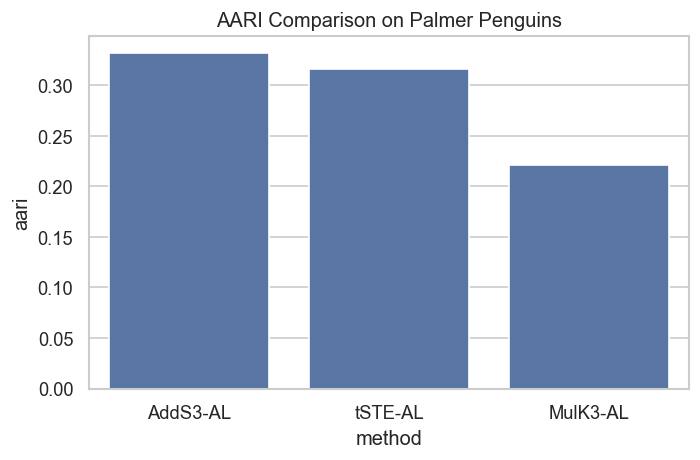

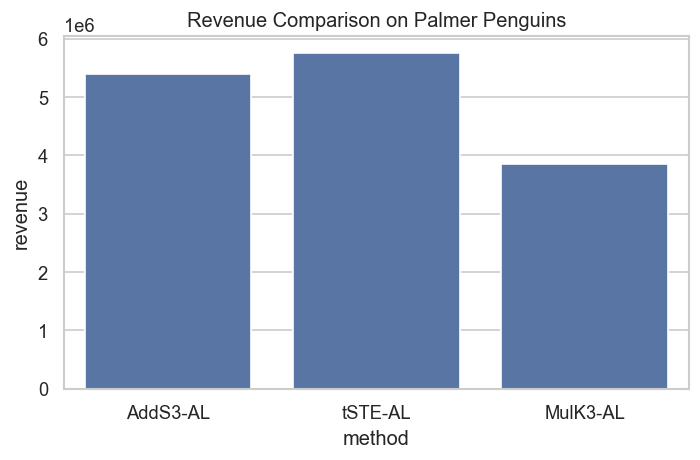

In [4]:
summary = (
    df_penguins
    .groupby("method", as_index=False)[["revenue", "aari"]]
    .mean()
    .sort_values("aari", ascending=False)
)

print("\n===== SUMMARY (MEAN) =====")
display(summary)

# ================= VISUALIZATION =================
plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x="method", y="aari")
plt.title("AARI Comparison on Palmer Penguins")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.barplot(data=summary, x="method", y="revenue")
plt.title("Revenue Comparison on Palmer Penguins")
plt.tight_layout()
plt.show()